## Introducción

## Setup del entorno

In [2]:
# Importamos las librerias necesarias:
from diffusers import StableDiffusionPipeline, DDPMScheduler
from diffusers import UNet2DConditionModel, AutoencoderKL, LMSDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from datasets import load_dataset
from accelerate import Accelerator
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

from dotenv import load_dotenv
from huggingface_hub import login

import gc


In [5]:
# Define cuántos hilos físicos quieres que use PyTorch como máximo
hilos_maximos = 4
torch.set_num_threads(hilos_maximos)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


## Modelo pre-entrenado (Comportamiento original)

In [7]:

# 1. Esto busca el archivo .env y carga sus variables en el entorno
load_dotenv()

# 2. Recuperamos el valor de la variable de forma segura
mi_token_hf = os.getenv("HF_TOKEN")

# 3. Iniciamos sesión en Hugging Face
login(token=mi_token_hf)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [11]:
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

# Cargamos un modelo pre-entrenado Stable Diffusion:
pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Imagen generada y guardada en: Imagen_inicial\football_player_inicial.png


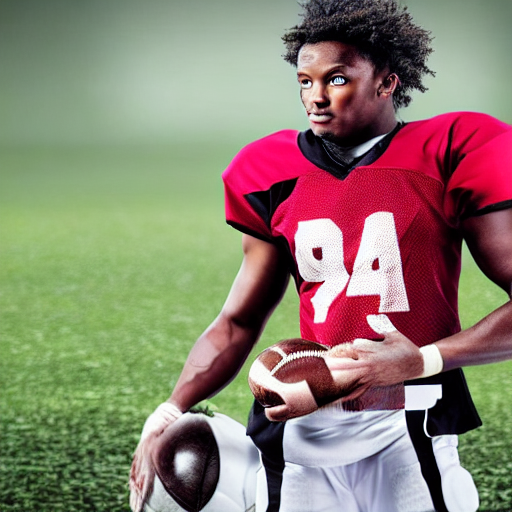

In [12]:
# Vamos a generar una imagen con un prompt:

# Crear la carpeta de destino si no existe
carpeta_salida_inicial = "Imagen_inicial"
os.makedirs(carpeta_salida_inicial, exist_ok=True)


prompt = "an image of a football player"
image = pipe(prompt).images[0]

# Guardamos la imagen finetuneada
ruta_inicio = os.path.join(carpeta_salida_inicial, "football_player_inicial.png")
image.save(ruta_inicio)

print(f"Imagen generada y guardada en: {ruta_inicio}")

image

## Cargamos el dataset para finetunear

In [7]:
# Cargando el dataset de libros antiguos con texto:
dataset_name = "gigant/oldbookillustrations"
max_train_samples = 50  # tiene que ser menor que 4.15K (el numero de filas que tiene el dataset original)


dataset = load_dataset(dataset_name, split="train")
if max_train_samples:
    dataset = dataset.select(range(max_train_samples))


In [8]:
#Inspeccionar dataset

print(dataset)
print(dataset.column_names)

Dataset({
    features: ['rawscan', '1600px', 'info_url', 'info_src', 'info_alt', 'artist_name', 'artist_birth_date', 'artist_death_date', 'artist_countries', 'book_title', 'book_authors', 'book_publishers', 'date_published', 'openlibrary-url', 'tags', 'illustration_source_name', 'illustration_source_url', 'illustration_subject', 'illustration_format', 'engravers', 'image_title', 'image_caption', 'image_description', 'rawscan_url', '1600px_url'],
    num_rows: 50
})
['rawscan', '1600px', 'info_url', 'info_src', 'info_alt', 'artist_name', 'artist_birth_date', 'artist_death_date', 'artist_countries', 'book_title', 'book_authors', 'book_publishers', 'date_published', 'openlibrary-url', 'tags', 'illustration_source_name', 'illustration_source_url', 'illustration_subject', 'illustration_format', 'engravers', 'image_title', 'image_caption', 'image_description', 'rawscan_url', '1600px_url']


In [9]:
#Comprobamos tamaño de una imagen del dataset

size = dataset[0]["1600px"].size
print(f"Tamaño de las imagenes del dataset: {size}")

Tamaño de las imagenes del dataset: (1158, 1600)


In [10]:
# Definimos las transformaciones necesarias para el dataset:
# La resolucion del modelo la podemos encontrar en su model card:
resolution = 512
image_transforms = transforms.Compose([
    transforms.Resize((resolution, resolution)),             # resizing
    transforms.ToTensor(),                                   # convertir a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # normalizacion
])

Imagen transformada:


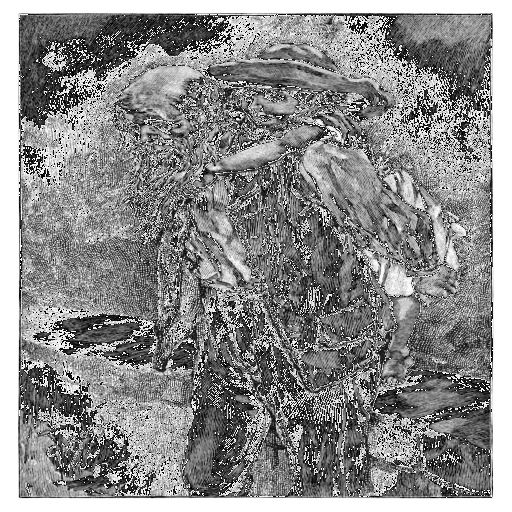

In [11]:
# Aplicamos la transformacion a la primera imagen del dataset:
original_image = dataset[0]["1600px"]
transformed_image = image_transforms(original_image)
transformed_pil_image = transforms.ToPILImage()(transformed_image)

print("Imagen transformada:")
transformed_pil_image

In [12]:
# Creamos un Dataset wrapper para la hora del entrenamiento

batch_size = 2

class Text2ImageDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = image_transforms(example["1600px"].convert("RGB"))      
        token = tokenizer(example["info_alt"], padding="max_length", truncation=True, max_length=tokenizer.model_max_length,
                return_tensors="pt")
        return {
            "pixel_values": image,
            "input_ids": token.input_ids.squeeze(0),
            "attention_mask": token.attention_mask.squeeze(0),
        }

train_dataset = Text2ImageDataset(dataset)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

## Cargamos las componentes del modelo por separado

In [13]:
# Liberamos el pipe que ya no necesitamos para hacer sitio en memoria:

if "pipe" in globals():
    del pipe
gc.collect()

18592

In [14]:
# Tokenizador:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder='tokenizer')

# Scheduler:
noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name, subfolder="scheduler")

# Text Encoder (CLIP):
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder",
).to(device)

# VAE: Autoencoder:
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae",
).to(device)

# La UNet:
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet",
).to(device)

c:\Users\victo\Pontia\Modulo_7\Entrega_Final_Modulo_7\venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [15]:
# Congelamos los pesos del VAE y del Text Encoder, ya que solo queremos finetunear la UNet:
vae.eval()
text_encoder.eval()

for param in vae.parameters():
    param.requires_grad = False
for param in text_encoder.parameters():
    param.requires_grad = False

## Preparamos el entrenamiento

In [16]:
# Optimizador:
learning_rate = 1e-5
optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

# Acelerador:
accelerator = Accelerator()
unet, optimizer, train_dataloader = accelerator.prepare(unet, optimizer, train_dataloader)
print(accelerator.device)

cpu


 ## Proceso de entrenamiento: finetuning

In [20]:
'''train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # <-- Reduce este número (prueba con 2 o 4)
    pin_memory=True
) '''

'train_dataloader = DataLoader(\n    train_dataset,\n    batch_size=batch_size,\n    shuffle=True,\n    num_workers=0, # <-- Reduce este número (prueba con 2 o 4)\n    pin_memory=True\n) '

In [17]:
# Training loop:
num_epochs = 2

for epoch in range(num_epochs):
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch}")

    for batch in progress_bar:

        # Se pasan los pixeles al espacio latente con el encoder del VAE:
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(accelerator.device)).latent_dist.sample()
            latents = latents * 0.18215

        # Proceso de difusion hacia delante:
        # 1. Creamos ruido aleatorio
        noise = torch.randn_like(latents)
        # 2. Cogemos un timestep aleatorio:
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device).long()
        # 3. Añadimos ruido al vector del espacio latente:
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Codificamos el texto:
        encoder_hidden_states = text_encoder(batch["input_ids"].to(accelerator.device))[0]

        # Con el vector con ruido, el timestep, y el vector de texto, hacemos la prediccion de ruido:
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Calculamos el error y actualizamos los parametros:
        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.set_postfix(loss=loss.item())

Epoch 1: 100%|██████████| 25/25 [1:53:30<00:00, 272.40s/it, loss=0.0342]


In [24]:
# Guardamos el modelo finetuneado:

print("Entrenamiento finalizado. Guardando el modelo...")

# Necesitamos extraer el UNet original para poder guardarlo correctamente.
unet_entrenado = accelerator.unwrap_model(unet)

# Reconstruir el Pipeline con el unet modificado
pipeline = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4", 
    unet=unet_entrenado,
    vae=vae,
    text_encoder=text_encoder
)

# Guardar todo en una carpeta local
directorio_salida = "./modelo_generador_v1"
pipeline.save_pretrained(directorio_salida)

print(f"Modelo guardado en: {directorio_salida}")

Entrenamiento finalizado. Guardando el modelo...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ./modelo_generador_v1


In [25]:
#Realizamos la inferencia de la imagen con el modelo finetuneado

# Crear la carpeta de destino si no existe
carpeta_salida = "Imagenes_finetuning_notebook"
os.makedirs(carpeta_salida, exist_ok=True)

# Cargar tu modelo fine-tuneado
ruta_modelo = "./modelo_generador_v1"

pipeline = StableDiffusionPipeline.from_pretrained(
    ruta_modelo
)

pipeline.to(device)

# Definimos el prompt para generar la imagen
prompt = "an image of a football player"

# Generamos la imagen
print("Generando imagen...")
resultado = pipeline(
    prompt=prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# Guardamos la imagen finetuneada
ruta_final = os.path.join(carpeta_salida, "football_player_finetuned.png")
resultado.save(ruta_final)

print(f"Imagen generada y guardada en: {ruta_final}")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Generando imagen...


  0%|          | 0/30 [00:00<?, ?it/s]

Imagen generada y guardada en: Imagenes_finetuning_notebook\football_player_finetuned.png


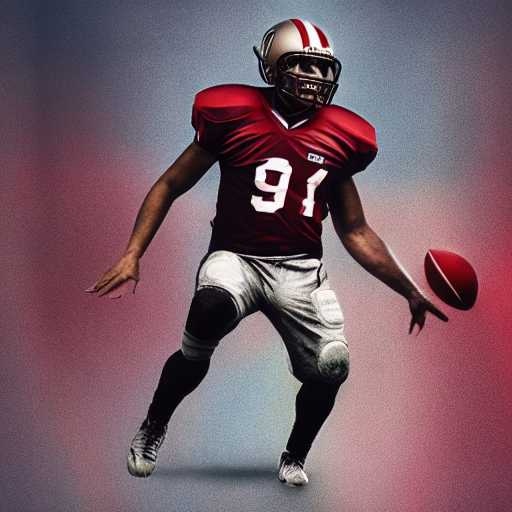

In [ ]:
#Mostrando la imagen funal finetuneada

resultado

In [3]:
# INFERENCIA UTILIZANDO MODELO FINETUNEADO SUBIDO A HUGGINGFACE

# Crear la carpeta de destino si no existe
carpeta_salida_hf = "Imagenes_finetuning_hf"
os.makedirs(carpeta_salida_hf, exist_ok=True)

# Usdamos el nombre del repositorio que subimos a Huggingface
model_id = "Victorh1397/stable-diffusion-v1-4-old-book-illustrations"

print(f"Descargando y cargando el pipeline desde: {model_id}...")

# Cargamos el pipeline
# Usamos torch.float16 si hay GPU para optimizar el uso de VRAM
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

# Enviamos el modelo al acelerador de hardware (GPU si está disponible)
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)
print(f"Modelo cargado exitosamente en: {device.upper()}")

# Definimos el prompt
prompt = "an image of a football player"

# Generamos la imagen
print(f"Generando imagen para el prompt: '{prompt}'...")
# Usamos un generador manual con una semilla fija si queremos tener resultados reproducibles
generator = torch.Generator(device).manual_seed(42) 
imagen_generada = pipe(prompt, num_inference_steps=50, guidance_scale=7.5, generator=generator).images[0]


# Guardamos la imagen finetuneada
ruta_final_hf = os.path.join(carpeta_salida_hf, "football_player_finetuned_hf.png")
imagen_generada.save(ruta_final_hf)

print(f"Imagen generada y guardada en: {ruta_final_hf}")




'''
# 6. Mostrar el resultado directamente en el notebook
plt.figure(figsize=(8, 8))
plt.imshow(imagen_generada)
plt.axis('off')
plt.title("Inferencia desde Hugging Face Hub")
plt.show()

# Opcional: Guardar la imagen en tu disco local
imagen_generada.save("resultado_hf_hub.png")
print("Imagen guardada como 'resultado_hf_hub.png'") '''

Descargando y cargando el pipeline desde: Victorh1397/stable-diffusion-v1-4-old-book-illustrations...


model_index.json:   0%|          | 0.00/712 [00:00<?, ?B/s]

c:\Users\victo\Pontia\Modulo_7\Entrega_Final_Modulo_7\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\victo\.cache\huggingface\hub\models--Victorh1397--stable-diffusion-v1-4-old-book-illustrations. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Modelo cargado exitosamente en: CPU
Generando imagen para el prompt: 'an image of a football player'...


  0%|          | 0/50 [00:00<?, ?it/s]

Imagen generada y guardada en: Imagenes_finetuning_hf\football_player_finetuned_hf.png


'\n# 6. Mostrar el resultado directamente en el notebook\nplt.figure(figsize=(8, 8))\nplt.imshow(imagen_generada)\nplt.axis(\'off\')\nplt.title("Inferencia desde Hugging Face Hub")\nplt.show()\n\n# Opcional: Guardar la imagen en tu disco local\nimagen_generada.save("resultado_hf_hub.png")\nprint("Imagen guardada como \'resultado_hf_hub.png\'") '

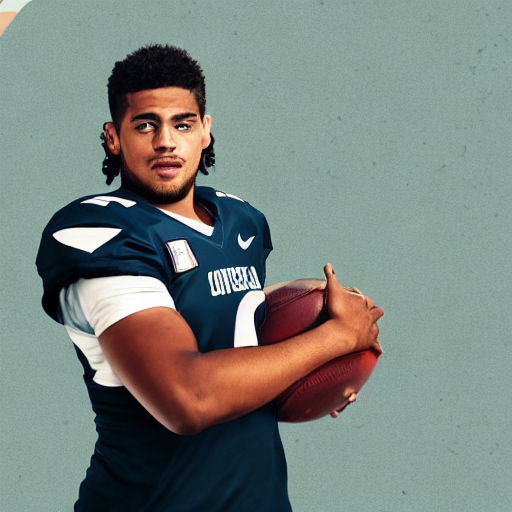

In [4]:
#Mostrando imagen generada con modelo finetuneado de huggingface

imagen_generada